In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('Telco-Customer-Churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode all other categorical columns
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Churn rate in train:", y_train.mean().round(3))

C:\Users\HP\AppData\Local\Temp\ipykernel_3392\227687346.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Train size: (5634, 19)
Test size: (1409, 19)
Churn rate in train: 0.265


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Logistic Regression (Baseline) ---
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]).round(4))

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    max_depth=10
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("\n=== Random Forest ===")
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]).round(4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8396

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC: 0.8382


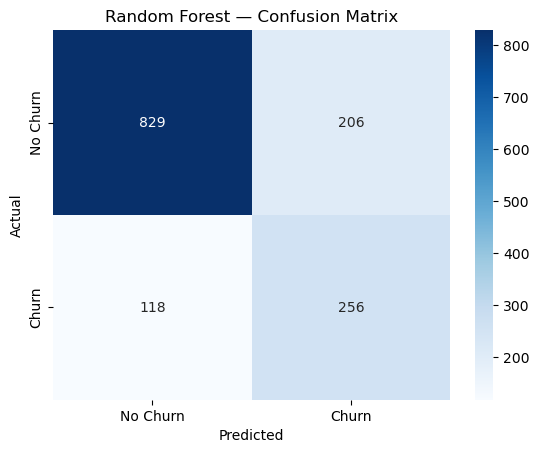

In [8]:
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

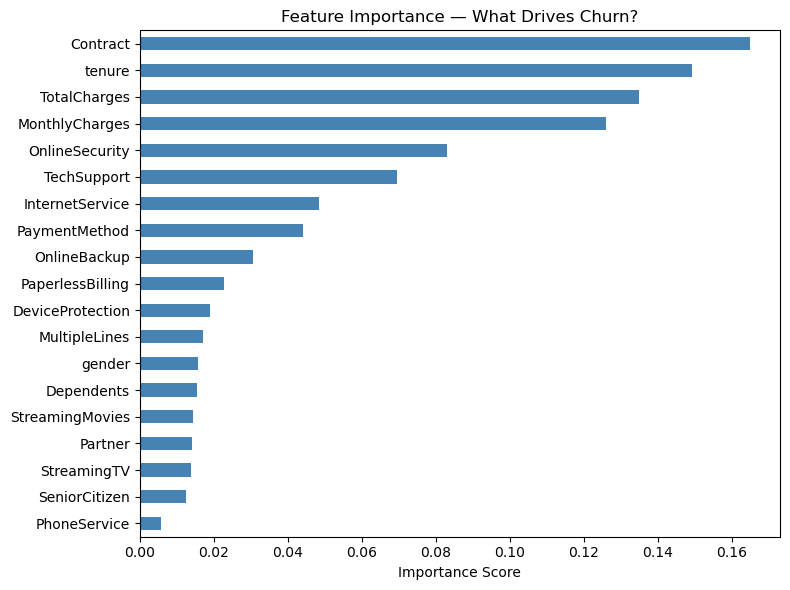

In [9]:
feature_names = df.drop('Churn', axis=1).columns

importances = pd.Series(rf.feature_importances_, index=feature_names)
importances.sort_values(ascending=True).plot(
    kind='barh', figsize=(8, 6), color='steelblue'
)
plt.title('Feature Importance — What Drives Churn?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [11]:
import pickle
import os

os.makedirs('model', exist_ok=True)

with open('model/rf_churn_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved successfully.")

Model saved successfully.


In [12]:
!streamlit --version

Streamlit, version 1.45.1
